In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time

def get_minute_bars(ticker):
    """
    Fetch minute-by-minute price data for a given stock ticker as far back as yahoo finance allows.

    Args:
    ticker (str): The stock ticker symbol.

    Returns:
    pandas.DataFrame: A DataFrame containing the minute-by-minute price data.
    """

    # Initialize the ticker object
    stock = yf.Ticker(ticker)

    # Set the end date to now and initialize an empty DataFrame for all data
    end_date = datetime.now()
    all_data = pd.DataFrame()

    # Function to fetch data with error handling
    def fetch_data(ticker, start, end, interval='1m'):
        try:
            df = ticker.history(start=start, end=end, interval=interval)
            if df.empty:
                raise ValueError("No data returned")
            return df
        except Exception as e:
            print(f"Error fetching data: {str(e)}")
            return pd.DataFrame()

    # Fetch data in 7-day intervals
    while True:
        start_date = end_date - timedelta(days=7)
        data = fetch_data(stock, start_date, end_date)
        
        if data.empty:
            break
        
        all_data = pd.concat([data, all_data])
        end_date = start_date
        
        print(f"Fetched data from {start_date} to {end_date}")
        
        # Add a 1 second sleep between requests
        time.sleep(0.5)

    if not all_data.empty:
        print(f"\nData retrieved for {ticker}")
        print(f"Total number of minutes of data: {len(all_data)}")
        print(f"Date range: {all_data.index[-1]} to {all_data.index[0]}")
        return all_data
    else:
        print(f"No data available for {ticker}.")
        return None


In [6]:
all_data = get_minute_bars('GC=F')

Fetched data from 2024-10-06 19:47:12.508024 to 2024-10-06 19:47:12.508024
Fetched data from 2024-09-29 19:47:12.508024 to 2024-09-29 19:47:12.508024
Fetched data from 2024-09-22 19:47:12.508024 to 2024-09-22 19:47:12.508024
Fetched data from 2024-09-15 19:47:12.508024 to 2024-09-15 19:47:12.508024


$GC=F: possibly delisted; no price data found  (1m 2024-09-08 19:47:12.508024 -> 2024-09-15 19:47:12.508024)


Error fetching data: No data returned

Data retrieved for GC=F
Total number of minutes of data: 27072
Date range: 2024-10-13 19:37:00-04:00 to 2024-09-15 19:48:00-04:00


In [7]:
all_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2024-09-15 19:48:00-04:00,2606.899902,2607.300049,2606.800049,2607.300049,0,0.0,0.0
2024-09-15 19:49:00-04:00,2607.399902,2607.699951,2607.300049,2607.699951,55,0.0,0.0
2024-09-15 19:50:00-04:00,2607.600098,2607.899902,2607.500000,2607.500000,69,0.0,0.0
2024-09-15 19:51:00-04:00,2607.399902,2607.399902,2607.100098,2607.100098,34,0.0,0.0
2024-09-15 19:52:00-04:00,2607.100098,2607.500000,2607.100098,2607.399902,25,0.0,0.0
...,...,...,...,...,...,...,...
2024-10-13 19:33:00-04:00,2666.399902,2666.399902,2666.100098,2666.300049,10,0.0,0.0
2024-10-13 19:34:00-04:00,2666.399902,2666.600098,2666.300049,2666.300049,17,0.0,0.0
2024-10-13 19:35:00-04:00,2666.300049,2666.800049,2666.000000,2666.699951,83,0.0,0.0


In [13]:
def mark_asia_open_zones(df, timeframe=4):
    """
    Mark the zones between Asia open and "timeframe" hours later on the dataframe.
    
    Args:
    df (pandas.DataFrame): The dataframe containing minute-by-minute price data.
    timeframe (int): The number of hours after Asia open to mark the zone.
    
    Returns:
    pandas.DataFrame: The dataframe with an additional 'Asia_Open_Zone' column.
    """
    # Ensure the index is timezone-aware in US/Eastern time
    df = df.tz_convert('US/Eastern')
    
    # Determine if each timestamp is in DST
    is_dst = df.index.map(lambda ts: ts.dst() != timedelta(0))

    # Map DST to asia_open_hour
    asia_open_hours = is_dst.map({True: 21, False: 20})

    # Compute asia_open_time and asia_close_time
    dates = df.index.normalize()
    asia_open_times = dates + pd.to_timedelta(asia_open_hours, unit='h')
    asia_close_times = asia_open_times + pd.Timedelta(hours=timeframe)

    # Create 'Asia_Open_Zone' column
    df['Asia_Open_Zone'] = (df.index >= asia_open_times) & (df.index < asia_close_times)
    
    return df

In [14]:
# Apply the function to the all_data dataframe
all_data = mark_asia_open_zones(all_data)

# Display the first few rows of the updated dataframe
print(all_data.head())

# Display some statistics about the Asia Open Zones
asia_open_data = all_data[all_data['Asia_Open_Zone']]
print(f"\nTotal number of minutes in Asia Open Zones: {len(asia_open_data)}")
print(f"Percentage of data in Asia Open Zones: {len(asia_open_data) / len(all_data) * 100:.2f}%")

                                  Open         High          Low        Close  \
Datetime                                                                        
2024-09-15 19:48:00-04:00  2606.899902  2607.300049  2606.800049  2607.300049   
2024-09-15 19:49:00-04:00  2607.399902  2607.699951  2607.300049  2607.699951   
2024-09-15 19:50:00-04:00  2607.600098  2607.899902  2607.500000  2607.500000   
2024-09-15 19:51:00-04:00  2607.399902  2607.399902  2607.100098  2607.100098   
2024-09-15 19:52:00-04:00  2607.100098  2607.500000  2607.100098  2607.399902   

                           Volume  Dividends  Stock Splits  Asia_Open_Zone  
Datetime                                                                    
2024-09-15 19:48:00-04:00       0        0.0           0.0           False  
2024-09-15 19:49:00-04:00      55        0.0           0.0           False  
2024-09-15 19:50:00-04:00      69        0.0           0.0           False  
2024-09-15 19:51:00-04:00      34        0.0   

In [24]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import mplfinance as mpf
import matplotlib.dates as mdates

def mark_asia_open_zones(df, timeframe=4):
    """
    Mark the zones between Asia open and "timeframe" hours later on the dataframe.
    
    Args:
    df (pandas.DataFrame): The dataframe containing minute-by-minute price data.
    timeframe (int): The number of hours after Asia open to mark the zone.
    
    Returns:
    pandas.DataFrame: The dataframe with an additional 'Asia_Open_Zone' column.
    """
    # Ensure the index is timezone-aware in US/Eastern time
    df = df.tz_convert('US/Eastern')

    # Determine if each timestamp is in DST
    is_dst = df.index.map(lambda ts: ts.dst() != timedelta(0))

    # Map DST to Asia open hour
    asia_open_hours = is_dst.map({True: 21, False: 20})

    # Compute Asia open time and close time
    dates = df.index.normalize()
    asia_open_times = dates + pd.to_timedelta(asia_open_hours, unit='h')
    asia_close_times = asia_open_times + pd.Timedelta(hours=timeframe)

    # Create 'Asia_Open_Zone' column
    df['Asia_Open_Zone'] = (df.index >= asia_open_times) & (df.index < asia_close_times)

    return df

def simulate_trading_strategy(df, starting_capital=10000, leverage=10, breakout_pct=0.2, trailing_stop_pct=0.2):
    """
    Simulate the trading strategy as per the specified rules, tracking capital and leverage.
    
    Args:
    df (pandas.DataFrame): The dataframe with minute-by-minute price data and 'Asia_Open_Zone' column.
    starting_capital (float): The starting capital for the strategy.
    leverage (float): The leverage multiplier to apply to trades.
    breakout_pct (float): Percentage of the range to consider as a breakout.
    trailing_stop_pct (float): Percentage of the range to set as the trailing stop.
    
    Returns:
    pandas.DataFrame: A dataframe containing the details of each trade executed.
    pandas.Series: A series representing the equity curve over time.
    """
    # Ensure the dataframe is sorted by index
    df = df.sort_index()

    # Create a unique ID for each Asia open session
    df['Asia_Open_Session_ID'] = (df['Asia_Open_Zone'] & (~df['Asia_Open_Zone'].shift(1).fillna(False))).cumsum()

    # Compute the high and low for each Asia open session
    asia_open_ranges = df[df['Asia_Open_Zone']].groupby('Asia_Open_Session_ID').agg({
        'High': 'max',
        'Low': 'min'
    }).rename(columns={'High': 'Asia_Open_High', 'Low': 'Asia_Open_Low'})

    # Forward-fill the session IDs and merge the Asia open ranges back into the dataframe
    df['Asia_Open_Session_ID'] = df['Asia_Open_Session_ID'].ffill()
    df = df.merge(asia_open_ranges, on='Asia_Open_Session_ID', how='left')

    # Calculate the range and breakout thresholds
    df['Asia_Open_Range'] = df['Asia_Open_High'] - df['Asia_Open_Low']
    df['Breakout_Threshold'] = breakout_pct * df['Asia_Open_Range']

    # Determine if each timestamp is after the Asia open session
    df['After_Asia_Open_Session'] = ~df['Asia_Open_Zone']

    # Initialize variables
    capital = starting_capital
    equity_curve = pd.Series(index=df.index, data=np.nan)
    all_trades = []

    # Process each Asia open session individually
    for session_id, group in df.groupby('Asia_Open_Session_ID'):
        trades, capital, equity_curve = process_trading_strategy(
            group, capital, leverage, equity_curve, breakout_pct, trailing_stop_pct
        )
        all_trades.extend(trades)

    # Convert the list of trades into a DataFrame
    trades_df = pd.DataFrame(all_trades)

    # Calculate total profit
    total_profit = trades_df['Profit'].sum()
    print(f"Total Profit: ${total_profit:.2f}")

    # Calculate ROI
    roi = (equity_curve.dropna().iloc[-1] - starting_capital) / starting_capital * 100
    print(f"Return on Investment (ROI): {roi:.2f}%")

    # Calculate win rate
    win_rate = (trades_df['Profit'] > 0).mean() * 100
    print(f"Win Rate: {win_rate:.2f}%")

    # Calculate average profit per trade
    average_profit = trades_df['Profit'].mean()
    print(f"Average Profit per Trade: ${average_profit:.2f}")

    return trades_df, equity_curve

def process_trading_strategy(group, capital, leverage, equity_curve, breakout_pct, trailing_stop_pct):
    """
    Process the trading strategy for a single Asia open session, updating capital and equity curve.
    
    Args:
    group (pandas.DataFrame): The dataframe for a single Asia open session.
    capital (float): The current capital.
    leverage (float): The leverage multiplier.
    equity_curve (pandas.Series): The equity curve series to update.
    breakout_pct (float): Percentage of the range to consider as a breakout.
    trailing_stop_pct (float): Percentage of the range to set as the trailing stop.
    
    Returns:
    list: A list of dictionaries containing trade details.
    float: Updated capital after processing the session.
    pandas.Series: Updated equity curve.
    """
    # Only process data after the Asia open session
    group = group[group['After_Asia_Open_Session']]

    # Initialize variables
    in_breakout = False
    breakout_direction = None  # 'up' or 'down'
    reentered_range = False
    trade_executed = False
    trades = []

    # Get the Asia open high, low, and range
    asia_open_high = group['Asia_Open_High'].iloc[0]
    asia_open_low = group['Asia_Open_Low'].iloc[0]
    asia_open_range = asia_open_high - asia_open_low
    breakout_threshold = breakout_pct * asia_open_range

    # Define breakout levels
    breakout_up_level = asia_open_high + breakout_threshold
    breakout_down_level = asia_open_low - breakout_threshold

    # Trailing stop value
    trailing_stop = trailing_stop_pct * asia_open_range

    position_size = 0  # Initialize position size

    for idx, row in group.iterrows():
        equity_curve[idx] = capital  # Update equity curve

        if not in_breakout:
            # Check for initial breakout
            if row['High'] >= breakout_up_level:
                in_breakout = True
                breakout_direction = 'up'
            elif row['Low'] <= breakout_down_level:
                in_breakout = True
                breakout_direction = 'down'
        elif not reentered_range:
            # Check if price re-enters the range
            if (breakout_direction == 'up' and row['Low'] <= asia_open_high):
                reentered_range = True
            elif (breakout_direction == 'down' and row['High'] >= asia_open_low):
                reentered_range = True
        elif not trade_executed:
            # Check for second breakout in the same direction
            if breakout_direction == 'up' and row['High'] >= breakout_up_level:
                # Execute a long trade
                trade_executed = True
                entry_price = row['Close']
                trade_time = idx
                # Calculate position size based on capital and leverage
                position_size = capital * leverage
                stop_loss = entry_price - trailing_stop
                trades.append({
                    'Time': trade_time,
                    'Direction': 'Long',
                    'Entry_Price': entry_price,
                    'Stop_Loss': stop_loss,
                    'Exit_Price': np.nan,
                    'Exit_Time': np.nan,
                    'Profit': np.nan,
                    'Capital_Before': capital,
                    'Capital_After': np.nan
                })
            elif breakout_direction == 'down' and row['Low'] <= breakout_down_level:
                # Execute a short trade
                trade_executed = True
                entry_price = row['Close']
                trade_time = idx
                position_size = capital * leverage
                stop_loss = entry_price + trailing_stop
                trades.append({
                    'Time': trade_time,
                    'Direction': 'Short',
                    'Entry_Price': entry_price,
                    'Stop_Loss': stop_loss,
                    'Exit_Price': np.nan,
                    'Exit_Time': np.nan,
                    'Profit': np.nan,
                    'Capital_Before': capital,
                    'Capital_After': np.nan
                })
        else:
            # Manage the trade with a trailing stop
            current_trade = trades[-1]
            if current_trade['Direction'] == 'Long':
                # Update trailing stop
                new_stop_loss = row['Close'] - trailing_stop
                if new_stop_loss > current_trade['Stop_Loss']:
                    current_trade['Stop_Loss'] = new_stop_loss
                # Check if stop loss is hit
                if row['Low'] <= current_trade['Stop_Loss']:
                    exit_price = current_trade['Stop_Loss']
                    exit_time = idx
                    profit_per_unit = exit_price - current_trade['Entry_Price']
                    profit = profit_per_unit * position_size / current_trade['Entry_Price']
                    capital += profit
                    current_trade.update({
                        'Exit_Price': exit_price,
                        'Exit_Time': exit_time,
                        'Profit': profit,
                        'Capital_After': capital
                    })
                    equity_curve[idx] = capital
                    break  # Exit after trade is closed
            elif current_trade['Direction'] == 'Short':
                # Update trailing stop
                new_stop_loss = row['Close'] + trailing_stop
                if new_stop_loss < current_trade['Stop_Loss']:
                    current_trade['Stop_Loss'] = new_stop_loss
                # Check if stop loss is hit
                if row['High'] >= current_trade['Stop_Loss']:
                    exit_price = current_trade['Stop_Loss']
                    exit_time = idx
                    profit_per_unit = current_trade['Entry_Price'] - exit_price
                    profit = profit_per_unit * position_size / current_trade['Entry_Price']
                    capital += profit
                    current_trade.update({
                        'Exit_Price': exit_price,
                        'Exit_Time': exit_time,
                        'Profit': profit,
                        'Capital_After': capital
                    })
                    equity_curve[idx] = capital
                    break  # Exit after trade is closed

    return trades, capital, equity_curve

def plot_trading_strategy(df, trades_df, equity_curve):
    """
    Plot the trading strategy on a candlestick chart, marking the Asia open zones and trade entries/exits.
    
    Args:
    df (pandas.DataFrame): The dataframe with price data and 'Asia_Open_Zone' marked.
    trades_df (pandas.DataFrame): The dataframe containing the details of each trade executed.
    equity_curve (pandas.Series): The equity curve over time.
    
    Returns:
    None
    """
    # Prepare data for mplfinance
    data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    data.index.name = 'Date'

    # Prepare the trade entry and exit markers
    entries = trades_df[['Time', 'Entry_Price']].dropna()
    exits = trades_df[['Exit_Time', 'Exit_Price']].dropna()

    # Set the Time columns as index
    entries.set_index('Time', inplace=True)
    exits.set_index('Exit_Time', inplace=True)

    # Prepare the markers
    apds = []

    if not entries.empty:
        entry_markers = mpf.make_addplot(entries['Entry_Price'], type='scatter', markersize=50, marker='^', color='green')
        apds.append(entry_markers)
    if not exits.empty:
        exit_markers = mpf.make_addplot(exits['Exit_Price'], type='scatter', markersize=50, marker='v', color='red')
        apds.append(exit_markers)

    # Add the equity curve as a separate subplot
    equity_curve = equity_curve.dropna()
    equity_plot = mpf.make_addplot(equity_curve, panel=1, color='blue', ylabel='Equity')

    apds.append(equity_plot)

    # Create a custom style to access axes after plotting
    s = mpf.make_mpf_style(base_mpf_style='classic', rc={'axes.grid': True})

    # Plot the candlestick chart
    fig, axlist = mpf.plot(data, type='candle', style=s, returnfig=True, addplot=apds, figsize=(12, 8), panel_ratios=(6, 2))

    ax = axlist[0]

    # Get the x-axis positions and the corresponding dates
    x_dates = data.index.map(mdates.date2num)
    date_to_x = dict(zip(data.index, x_dates))

    # Add the Asia open zones as shaded areas
    for session_id, session_data in df.groupby('Asia_Open_Session_ID'):
        asia_open_zone = session_data[session_data['Asia_Open_Zone']]
        if not asia_open_zone.empty:
            start_time = asia_open_zone.index[0]
            end_time = asia_open_zone.index[-1]
            x_start = date_to_x[start_time]
            x_end = date_to_x[end_time]
            ax.axvspan(x_start, x_end, color='yellow', alpha=0.3)

    plt.show()


C:\Users\SamAl\AppData\Local\Temp\ipykernel_19164\367935241.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Asia_Open_Session_ID'] = (df['Asia_Open_Zone'] & (~df['Asia_Open_Zone'].shift(1).fillna(False))).cumsum()


Total Profit: $-720.81
Return on Investment (ROI): -7.21%
Win Rate: 18.75%
Average Profit per Trade: $-45.05


d:\repos\Trading-Strategies\venv\lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


ValueError: x and y must be the same size

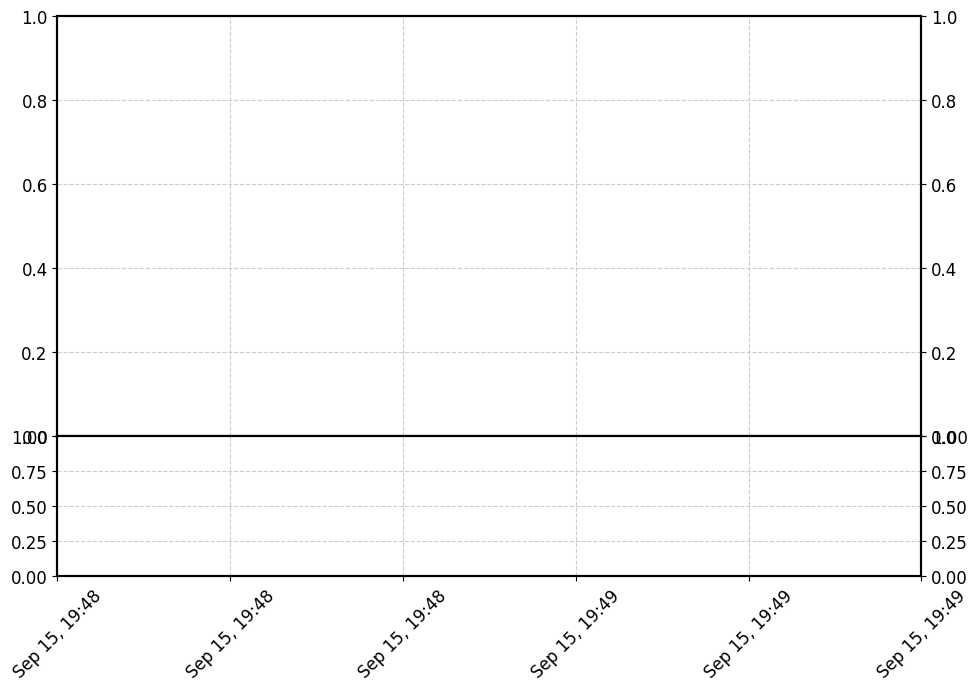

In [25]:
# Example usage:

# Assuming 'df' is your dataframe with price data and 'Asia_Open_Zone' marked
# df = pd.read_csv('your_data.csv', index_col=0, parse_dates=True)
# df = df.tz_localize('UTC')  # Adjust if your data is in UTC
# df = mark_asia_open_zones(df)

# Simulate the trading strategy with starting capital and leverage
trades_df, equity_curve = simulate_trading_strategy(
    all_data, starting_capital=10000, leverage=10, breakout_pct=0.2, trailing_stop_pct=0.2
)
# Plot the strategy
plot_trading_strategy(all_data, trades_df, equity_curve)
